# Young Midfielder Recruitment Analysis — Europe's Big Five Leagues, 2024/25

This project develops a simple statistical screening framework for midfielders
aged 23 or younger in Europe's Big Five leagues.

The goal is to compare players across different areas of performance and identify candidates who may
fit specific recruitment requirements.

The dataset was obtained from Kaggle.

In [1]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("hubertsidorowicz/football-players-stats-2024-2025")

print("Path to dataset files:", path)

df = pd.read_csv(
    os.path.join(path, "players_data-2024_2025.csv")
)
print(df.head())

print(df.shape)

Path to dataset files: C:\Users\15388\.cache\kagglehub\datasets\hubertsidorowicz\football-players-stats-2024-2025\versions\43
   Rk             Player   Nation    Pos        Squad                Comp  \
0   1         Max Aarons  eng ENG     DF  Bournemouth  eng Premier League   
1   2         Max Aarons  eng ENG  DF,MF     Valencia          es La Liga   
2   3     Rodrigo Abajas   es ESP     DF     Valencia          es La Liga   
3   4     James Abankwah   ie IRL  DF,MF      Udinese          it Serie A   
4   5  Keyliane Abdallah   fr FRA     FW    Marseille          fr Ligue 1   

    Age    Born  MP  Starts  ...  Att (GK)  Thr  Launch%  AvgLen  Opp  Stp  \
0  24.0  2000.0   3       1  ...       NaN  NaN      NaN     NaN  NaN  NaN   
1  24.0  2000.0   4       1  ...       NaN  NaN      NaN     NaN  NaN  NaN   
2  21.0  2003.0   1       1  ...       NaN  NaN      NaN     NaN  NaN  NaN   
3  20.0  2004.0   6       0  ...       NaN  NaN      NaN     NaN  NaN  NaN   
4  18.0  2006.0   1  

The original dataset contains a large number of variables from different aspects of player performance. For this analysis, I selected variables relevant to midfielder recruitment, including passing, chance creation, carrying, dribbling, defending, and aerial ability.

In [2]:
basic = [
    "Player",
    "Age",
    "Squad",
    "Comp",
    "Pos",
    "Min",
    "90s"
]

passing = [
    "Att",        # Pass attempts
    "Cmp",        # Completed passes
    "Cmp%",        # Pass accuracy
    "TotDist",      # Total passing distance
    "PrgP",       # Progressive passes
    "PrgDist",    # Progressive passing distance
    "1/3",        # Passes into final third
    "PPA"         # Passes into penalty area
]

creation = [
    "KP",         # Key passes
    "xAG",        # Expected assisted goals
]

dribbling = [
    "Att_stats_possession",  # Take-ons attempted
    "Succ",                  # Successful take-ons
    "Succ%",                 # Take-on success %
    "Tkld",                  # Tackled during take-on
    "Tkld%"                  # % of take-ons tackled
]

carrying = [
    "Carries",
    "PrgC",                       # Progressive carries
    "PrgDist_stats_possession",   # Progressive carrying distance
    "1/3_stats_possession",       # Carries into final third
    "CPA"                         # Carries into penalty area
]

defending = [
    "Tkl",      # Tackles  
    "TklW",     # Tackle wins  
    "Int",      
    "Tkl+Int",
    "Recov",
    "Blocks_stats_defense"
]

aerial  = [
    "Won",        #aerial duels
    "Won%"        
]

context = [
    "Touches"
]

columns = (
    basic
    + passing
    + creation
    + dribbling
    + carrying
    + defending
    + aerial
    + context
)

player_data = df[columns].copy()

To focus the analysis, I restrict the sample to midfielders aged 23 or younger.

In [3]:
young_MidFielder = player_data[(player_data["Age"] <= 23) &
                               (player_data["Pos"].str.contains("MF"))]

The data may not accurately represent a player's performance if the player has limited playing time. Therefore, a minimum minutes threshold is applied. A threshold of 900 minutes, roughly equivalent to ten full matches, was chosen as a compromise between improving the stability of per-90 statistics and retaining a sufficiently large group of young players.

count     594.000000
mean      971.659933
std       896.691597
min         1.000000
25%       150.500000
50%       761.000000
75%      1663.000000
max      3351.000000
Name: Min, dtype: float64
Total: 594
500+: 336
900+: 276
1200+: 216


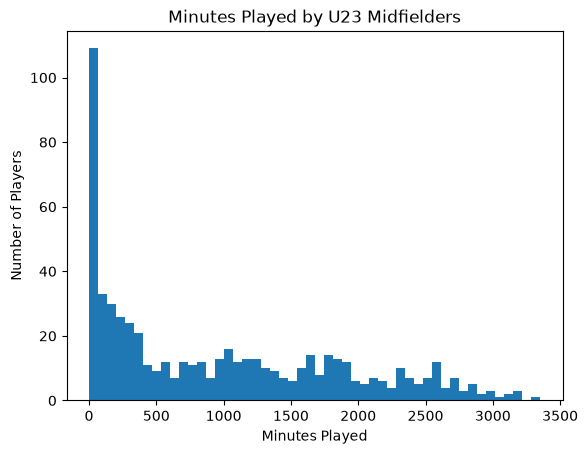

In [4]:
print(young_MidFielder["Min"].describe())
print("Total:", len(young_MidFielder))
print("500+:", (young_MidFielder["Min"] >= 500).sum())
print("900+:", (young_MidFielder["Min"] >= 900).sum())
print("1200+:", (young_MidFielder["Min"] >= 1200).sum())
fig, ax = plt.subplots()

ax.hist(
    young_MidFielder["Min"],
    bins=50
)

ax.set_xlabel("Minutes Played")
ax.set_ylabel("Number of Players")
ax.set_title("Minutes Played by U23 Midfielders")

plt.show()


young_MidFielder_Talents = young_MidFielder[young_MidFielder["Min"] >= 900]


### Summary of the Filtered Sample

               Player   Age     Squad                Comp    Pos   Min   90s  \
29      Karim Adeyemi  22.0  Dortmund       de Bundesliga  FW,MF  1433  15.9   
30      Simon Adingra  22.0  Brighton  eng Premier League  FW,MF  1097  12.2   
43      Lucien Agoume  22.0   Sevilla          es La Liga     MF  2114  23.5   
66  Maghnes Akliouche  22.0    Monaco          fr Ligue 1  FW,MF  2406  26.7   
85    Mohamed Ali Cho  20.0      Nice          fr Ligue 1  FW,MF  1621  18.0   

     Att   Cmp  Cmp%  ...  CPA  Tkl  TklW  Int  Tkl+Int  Recov  \
29   401   298  74.3  ...   41   20    14    7       27     48   
30   382   290  75.9  ...   27   23    14    8       31     47   
43  1236  1007  81.5  ...    2   70    32   41      111    136   
66  1216   989  81.3  ...   47   51    31   15       66    131   
85   481   338  70.3  ...   30   13     9    5       18     69   

    Blocks_stats_defense  Won  Won%  Touches  
29                    14    9  40.9      636  
30                    12    

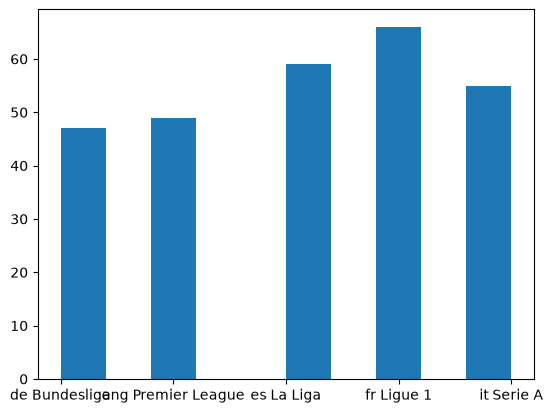

Age
16.0     1
18.0    11
19.0    26
20.0    39
21.0    48
22.0    68
23.0    83
Name: count, dtype: int64


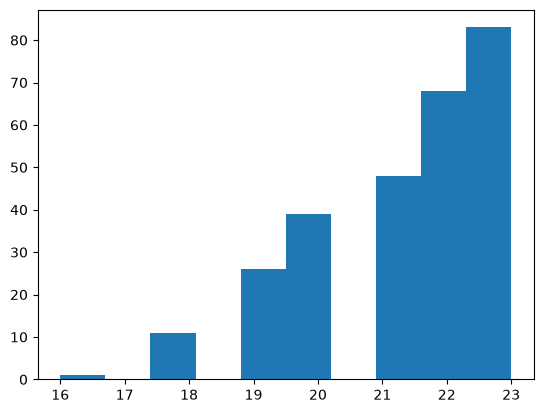

Pos
MF       112
FW,MF     69
MF,FW     52
DF,MF     22
MF,DF     21
Name: count, dtype: int64


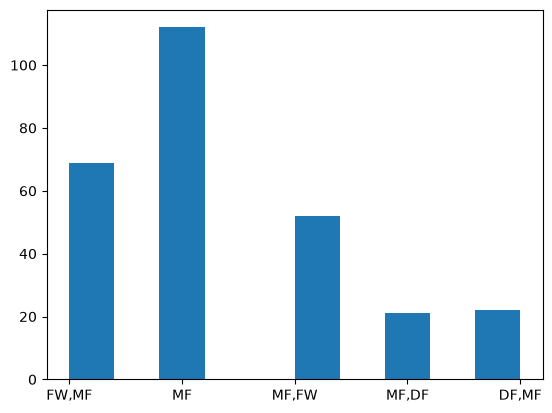

In [5]:
print(young_MidFielder_Talents.head())
print(young_MidFielder_Talents.shape)

print(young_MidFielder_Talents["Comp"].value_counts())
plt.hist(young_MidFielder_Talents["Comp"])
plt.show()

print(young_MidFielder_Talents["Age"].value_counts().sort_index())
plt.hist(young_MidFielder_Talents["Age"])
plt.show()
print(young_MidFielder_Talents["Pos"].value_counts())
plt.hist(young_MidFielder_Talents["Pos"])
plt.show()

There is an important distinction between players listed as "FW,MF" or "DF,MF" and those listed primarily as midfielders. For simplicity, this analysis only includes players whose positions are listed as "MF", "MF,FW", or "MF,DF".

In [6]:
eligible_Mf = young_MidFielder_Talents[
    young_MidFielder_Talents["Pos"].isin(["MF", "MF,DF", "MF,FW"])]

print(eligible_Mf.head())

eligible_Mf = eligible_Mf.copy()

              Player   Age            Squad                Comp    Pos   Min  \
43     Lucien Agoume  22.0          Sevilla          es La Liga     MF  2114   
91     Thiago Almada  23.0             Lyon          fr Ligue 1  MF,FW   951   
99    Sergi Altimira  22.0            Betis          es La Liga     MF  1972   
102     Hugo Álvarez  21.0       Celta Vigo          es La Liga  MF,DF  1572   
123  Elliot Anderson  21.0  Nott'ham Forest  eng Premier League     MF  2728   

      90s   Att   Cmp  Cmp%  ...  CPA  Tkl  TklW  Int  Tkl+Int  Recov  \
43   23.5  1236  1007  81.5  ...    2   70    32   41      111    136   
91   10.6   748   635  84.9  ...   10   14     8    7       21     56   
99   21.9  1258  1123  89.3  ...    1   61    37   24       85    117   
102  17.5  1013   799  78.9  ...   41   26     9    8       34     78   
123  30.3  1386  1085  78.3  ...   21   92    56   31      123    207   

     Blocks_stats_defense  Won  Won%  Touches  
43                     30   42  

### Exploratory Analysis

#### Converting Metrics to Per 90 Minutes

Players have different amounts of playing time, so raw count statistics are not directly comparable. To make comparisons more meaningful, count-based metrics are converted to a per-90-minute basis.

In [7]:
per90 = [
    "Att", "Cmp", "PrgP", "TotDist", "PrgDist", "1/3", "PPA",
    "KP", "xAG", "Att_stats_possession", "Succ", "Tkld", 
    "Carries", "PrgC", "PrgDist_stats_possession",
    "1/3_stats_possession", "CPA",
    "Tkl", "TklW", "Int", "Tkl+Int", "Recov", "Blocks_stats_defense",
    "Won", "Touches"
]

metrics_column = [
    "Cmp%", "Succ%", "Tkld%","Won%"
]
for i in per90:
    eligible_Mf[f"{i}_per90"] = (
        eligible_Mf[i] / eligible_Mf["90s"]
    )
    metrics_column.append(f"{i}_per90")

#### Distribution of Minutes Played

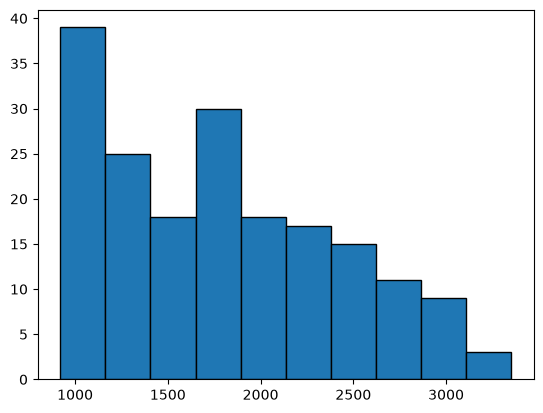

In [8]:
plt.hist(eligible_Mf["Min"], edgecolor="black")
plt.show()

A scatter plot of completed passes per 90 minutes vs. pass accuracy.

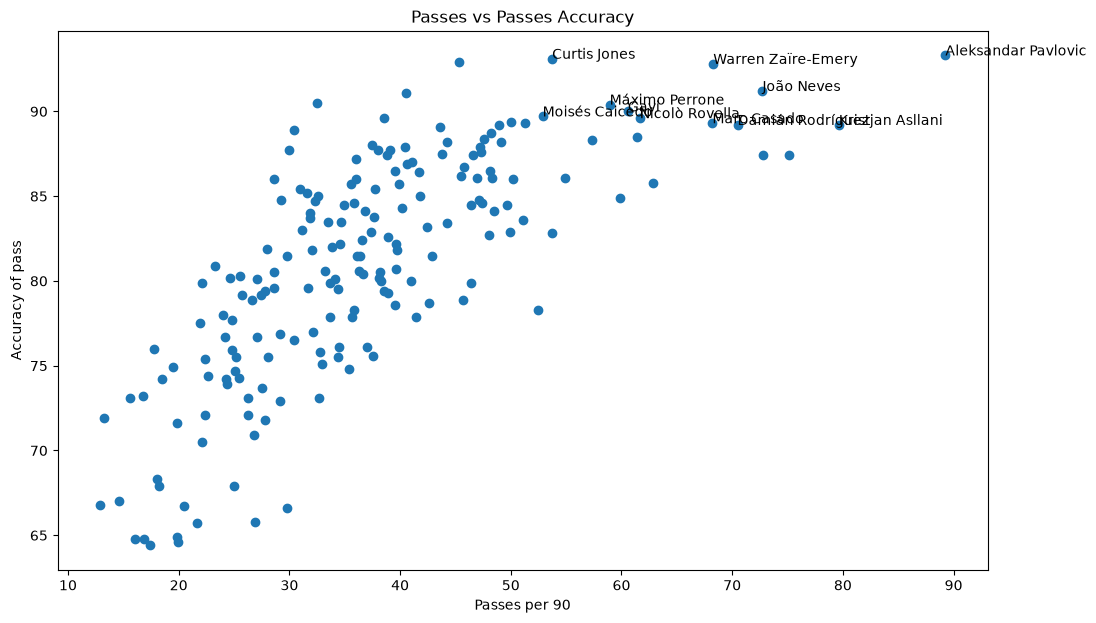

count    185.000000
mean      21.275676
std        1.490806
min       16.000000
25%       20.000000
50%       21.000000
75%       23.000000
max       23.000000
Name: Age, dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(eligible_Mf["Cmp_per90"], eligible_Mf["Cmp%"])
cmp_cutoff = eligible_Mf["Cmp_per90"].quantile(0.9)
acc_cutoff = eligible_Mf["Cmp%"].quantile(0.9)
key_players_pass = eligible_Mf[
    (eligible_Mf["Cmp_per90"] >= cmp_cutoff) &
    (eligible_Mf["Cmp%"] >= acc_cutoff)
]
for i, row in key_players_pass.iterrows():
    plt.annotate(
        row["Player"],
        (row["Cmp_per90"], row["Cmp%"])
    )
ax.set_xlabel("Passes per 90")
ax.set_ylabel("Accuracy of pass")
ax.set_title("Passes vs Passes Accuracy")

plt.show()

print(eligible_Mf["Age"].describe())

Pass Volume vs Progressive Passing

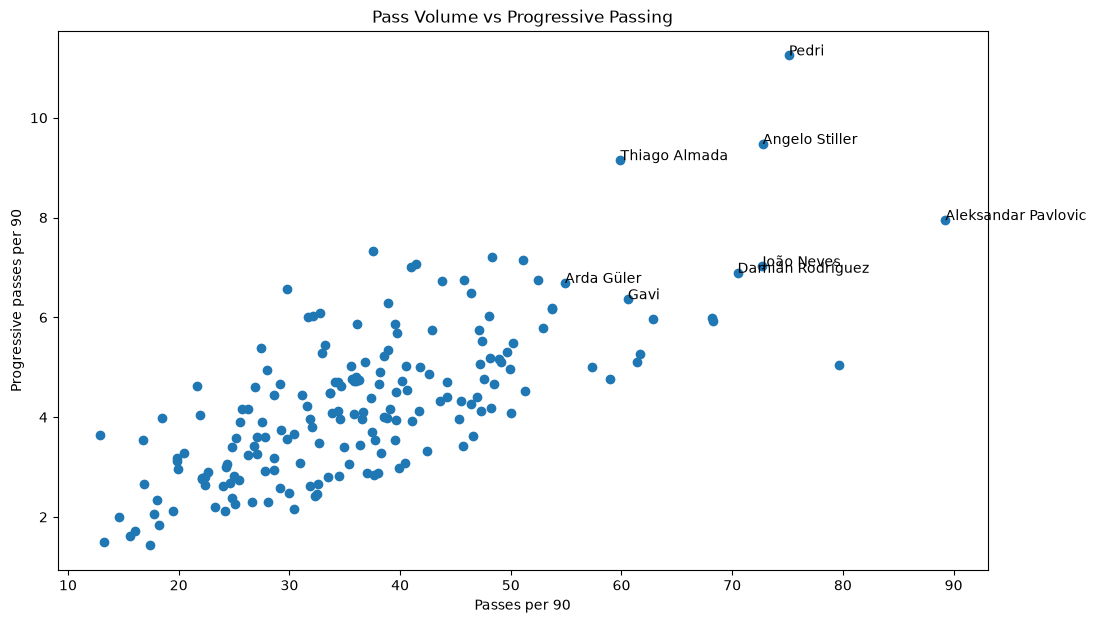

In [10]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(eligible_Mf["Cmp_per90"], eligible_Mf["PrgP_per90"])
prgP_cutoff = eligible_Mf["PrgP_per90"].quantile(0.9)
key_players_prgPass = eligible_Mf[
    (eligible_Mf["Cmp_per90"] >= cmp_cutoff) &
    (eligible_Mf["PrgP_per90"] >= prgP_cutoff)
]
for i, row in key_players_prgPass.iterrows():
    plt.annotate(
        row["Player"],
        (row["Cmp_per90"], row["PrgP_per90"])
    )
ax.set_xlabel("Passes per 90")
ax.set_ylabel("Progressive passes per 90")
ax.set_title("Pass Volume vs Progressive Passing")

plt.show()

Pass Volume vs Passes into the Penalty Area

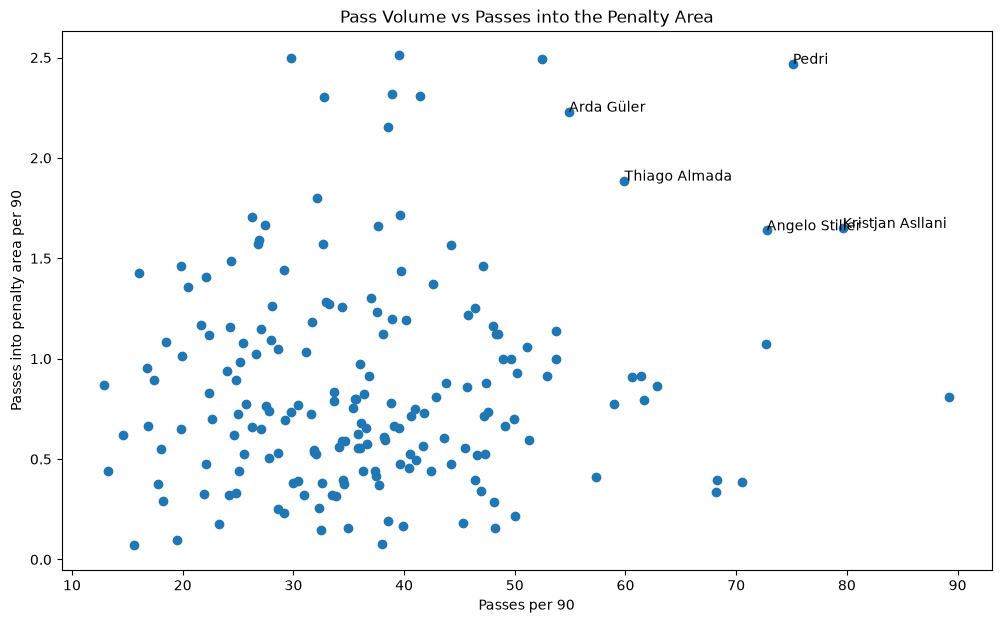

In [11]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(eligible_Mf["Cmp_per90"], eligible_Mf["PPA_per90"])
PPA_cutoff = eligible_Mf["PPA_per90"].quantile(0.9)
key_players_Ppass = eligible_Mf[
    (eligible_Mf["Cmp_per90"] >= cmp_cutoff) &
    (eligible_Mf["PPA_per90"] >= PPA_cutoff)
]
for i, row in key_players_Ppass.iterrows():
    plt.annotate(
        row["Player"],
        (row["Cmp_per90"], row["PPA_per90"])
    )
ax.set_xlabel("Passes per 90")
ax.set_ylabel("Passes into penalty area per 90")
ax.set_title("Pass Volume vs Passes into the Penalty Area")

plt.show()

Successful take-ons per 90 vs Take-on Success Rate

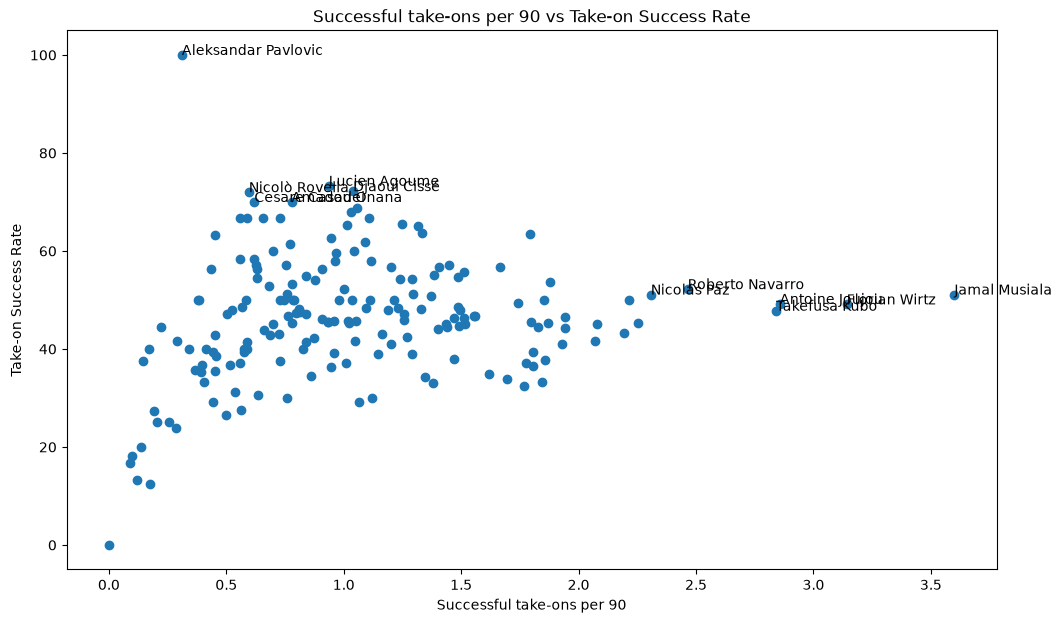

In [12]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(eligible_Mf["Succ_per90"], eligible_Mf["Succ%"])
takeon_cutoff = eligible_Mf["Succ_per90"].quantile(0.97)
succpercent_cutoff = eligible_Mf["Succ%"].quantile(0.97)
key_players_takeon = eligible_Mf[
    (eligible_Mf["Succ_per90"] >= takeon_cutoff) |
    (eligible_Mf["Succ%"] >= succpercent_cutoff)
]
for i, row in key_players_takeon.iterrows():
    plt.annotate(
        row["Player"],
        (row["Succ_per90"], row["Succ%"])
    )
ax.set_xlabel("Successful take-ons per 90")
ax.set_ylabel("Take-on Success Rate")
ax.set_title("Successful take-ons per 90 vs Take-on Success Rate")

plt.show()

Progressive Passes vs Progressive Carries

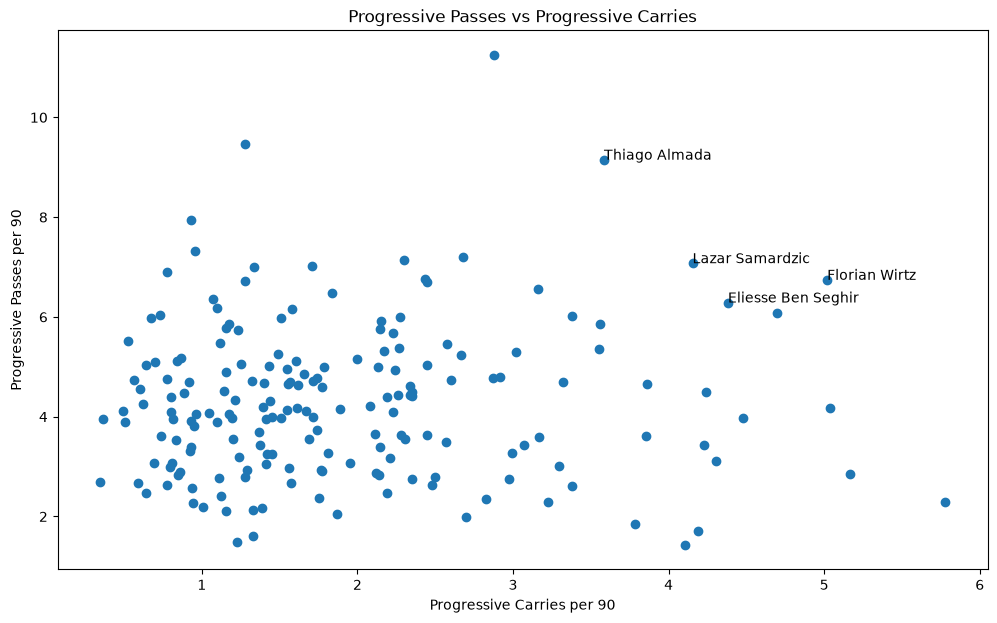

In [13]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(eligible_Mf["PrgC_per90"], eligible_Mf["PrgP_per90"])
prgC_cutoff = eligible_Mf["PrgC_per90"].quantile(0.9)
key_players_carries = eligible_Mf[
    (eligible_Mf["PrgC_per90"] >= prgC_cutoff) &
    (eligible_Mf["PrgP_per90"] >= prgP_cutoff)
]
for i, row in key_players_carries.iterrows():
    plt.annotate(
        row["Player"],
        (row["PrgC_per90"], row["PrgP_per90"])
    )
ax.set_xlabel("Progressive Carries per 90")
ax.set_ylabel("Progressive Passes per 90")
ax.set_title("Progressive Passes vs Progressive Carries")
plt.show()

Tackles + Interceptions vs Blocks

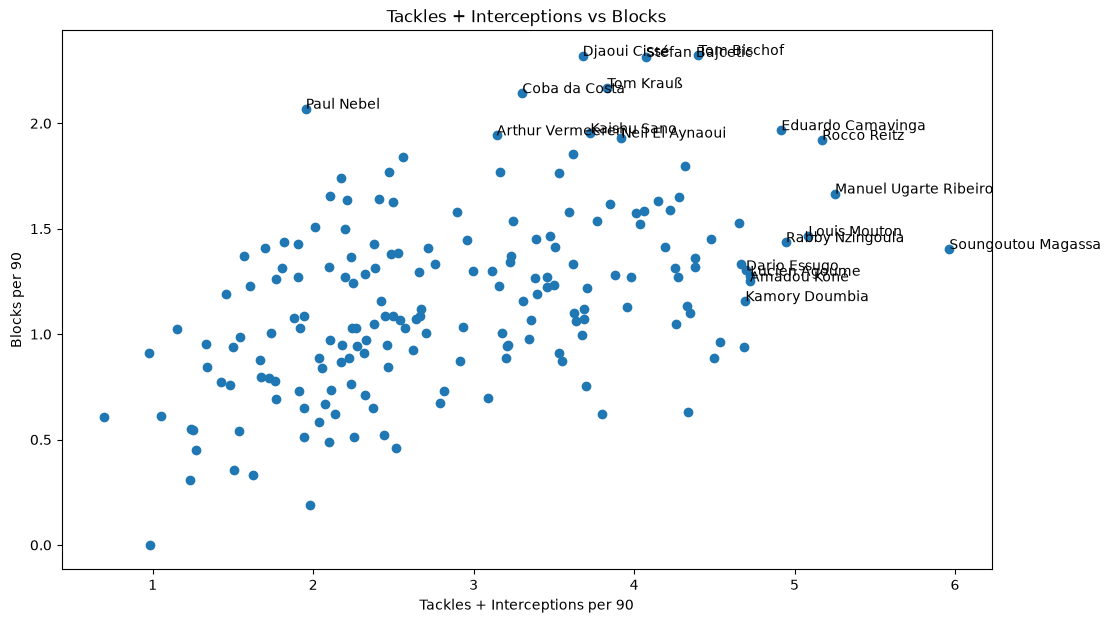

In [14]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(eligible_Mf["Tkl+Int_per90"], eligible_Mf["Blocks_stats_defense_per90"])
tklInt_cutoff = eligible_Mf["Tkl+Int_per90"].quantile(0.95)
blocks_cutoff = eligible_Mf["Blocks_stats_defense_per90"].quantile(0.95)
key_players_defense = eligible_Mf[
    (eligible_Mf["Tkl+Int_per90"] >= tklInt_cutoff) |
    (eligible_Mf["Blocks_stats_defense_per90"] >= blocks_cutoff)
]
for i, row in key_players_defense.iterrows():
    plt.annotate(
        row["Player"],
        (row["Tkl+Int_per90"], row["Blocks_stats_defense_per90"])
    )
ax.set_xlabel("Tackles + Interceptions per 90")
ax.set_ylabel("Blocks per 90")
ax.set_title("Tackles + Interceptions vs Blocks")

plt.show()

Aerial duels won per 90 vs Aerial Duel Win Rate

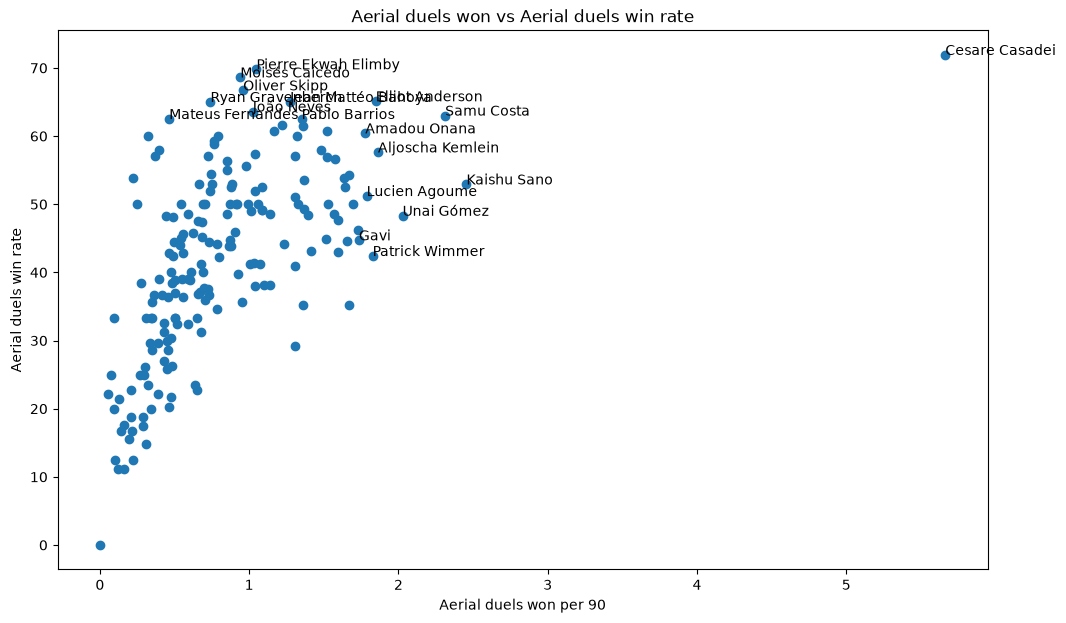

In [15]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(eligible_Mf["Won_per90"], eligible_Mf["Won%"])
won_cutoff = eligible_Mf["Won_per90"].quantile(0.95)
won_percent_cutoff = eligible_Mf["Won%"].quantile(0.95)
key_players_duel = eligible_Mf[
    (eligible_Mf["Won_per90"] >= won_cutoff) |
    (eligible_Mf["Won%"] >= won_percent_cutoff)
]
for i, row in key_players_duel.iterrows():
    plt.annotate(
        row["Player"],
        (row["Won_per90"], row["Won%"])
    )
ax.set_xlabel("Aerial duels won per 90")
ax.set_ylabel("Aerial duels win rate")
ax.set_title("Aerial duels won vs Aerial duels win rate")

plt.show()

## Metric Selection and Redundancy

Some performance metrics may measure similar aspects of a player's game. 
Correlations between candidate metrics are examined to reduce redundancy before constructing player profiles.

In [16]:
corr_matrix = eligible_Mf[metrics_column].corr()

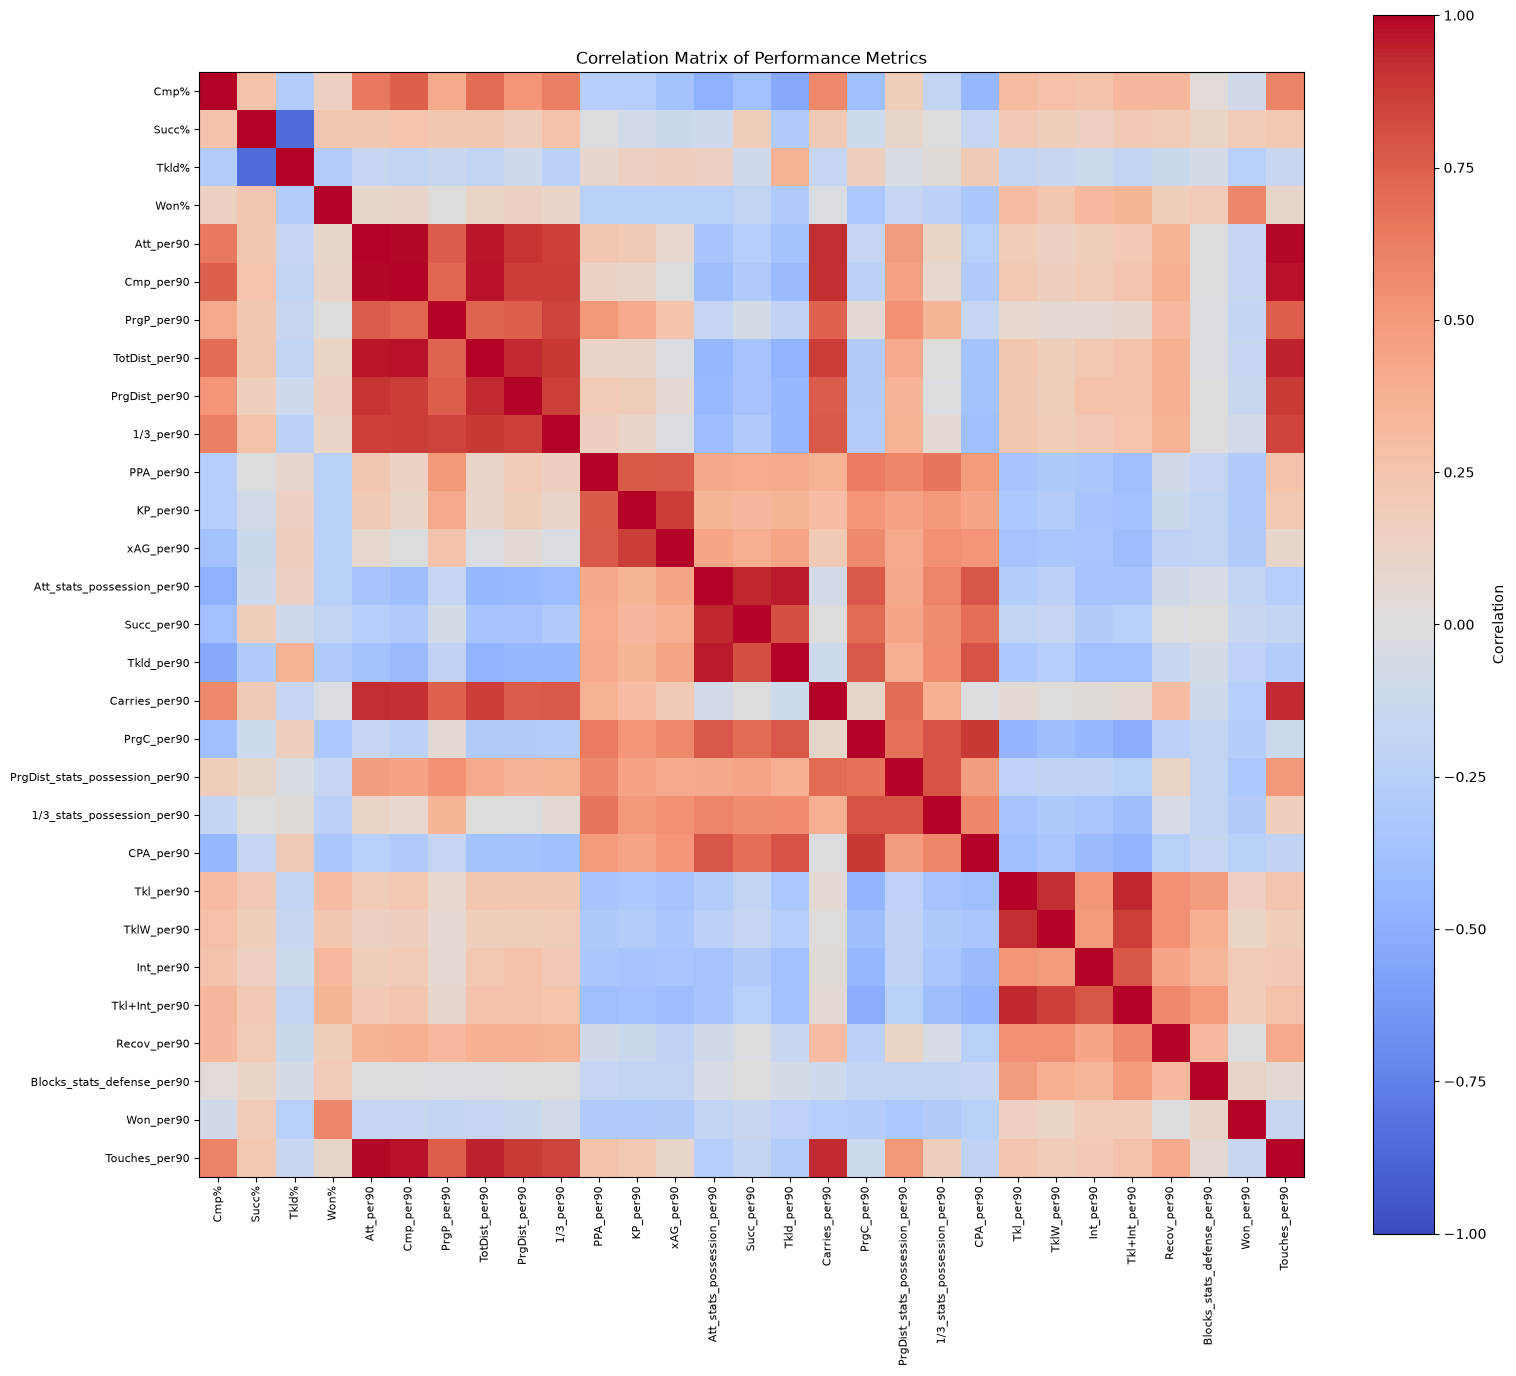

In [17]:
fig, ax = plt.subplots(figsize=(16, 14))

heatmap = ax.imshow(
    corr_matrix,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))

ax.set_xticklabels(
    corr_matrix.columns,
    rotation=90,
    fontsize=8
)

ax.set_yticklabels(
    corr_matrix.columns,
    fontsize=8
)

fig.colorbar(heatmap, ax=ax, label="Correlation")

ax.set_title("Correlation Matrix of Performance Metrics")

plt.tight_layout()
plt.show()

In [18]:
high_corr = []

for i in range(len(metrics_column)):
    for j in range(i + 1, len(metrics_column)):
        corr = corr_matrix.loc[
            metrics_column[i],
            metrics_column[j]
        ]

        if abs(corr) >= 0.8:
            high_corr.append([
                metrics_column[i],
                metrics_column[j],
                corr
            ])

high_corr_df = pd.DataFrame(
    high_corr,
    columns=["Metric 1", "Metric 2", "Correlation"]
)

high_corr_df

,Metric 1,Metric 2,Correlation
0,Succ%,Tkld%,-0.858621
1,Att_per90,Cmp_per90,0.987418
2,Att_per90,TotDist_per90,0.967931
3,Att_per90,PrgDist_per90,0.897221
4,Att_per90,1/3_per90,0.863345
5,Att_per90,Carries_per90,0.914405
6,Att_per90,Touches_per90,0.987357
7,Cmp_per90,TotDist_per90,0.973210
8,Cmp_per90,PrgDist_per90,0.872645
9,Cmp_per90,1/3_per90,0.869973


Several metrics were removed after examining both their correlations and their football meaning.

Some metrics were highly correlated and also represented very similar actions, so I removed a few of them. 

For example, `Cmp_per90` and `Att_per90` had a correlation of about 0.99. I kept `Att_per90` as a measure of passing volume and `Cmp%` as a measure of accuracy.

For take-ons, I kept attempts per 90 and success percentage instead of also using successful and tackled take-ons per 90, since these variables contained a lot of overlapping information.

For defending, `Tkl_per90` and `TklW_per90` were removed because they overlapped with `Tkl+Int_per90`.

I did not remove variables based only on a correlation threshold. For example, `KP_per90` and `xAG_per90` were highly correlated, but I kept both because they describe different aspects of chance creation.

In [19]:
selected_metrics = [
    # Passing / involvement
    "Att_per90",
    "Cmp%",

    # Progression
    "PrgP_per90",
    "1/3_per90",
    "PPA_per90",

    # Creation
    "KP_per90",
    "xAG_per90",

    # Ball_Carrying
    "Att_stats_possession_per90",
    "Succ%",
    "PrgC_per90",
    "CPA_per90",

    # Defending
    "Tkl+Int_per90",
    "Recov_per90",
    "Blocks_stats_defense_per90",

    # Aerial
    "Won_per90",
    "Won%",
]
eligible_Mf[selected_metrics].isna().sum()

Att_per90                     0
Cmp%                          0
PrgP_per90                    0
1/3_per90                     0
PPA_per90                     0
KP_per90                      0
xAG_per90                     0
Att_stats_possession_per90    0
Succ%                         0
PrgC_per90                    0
CPA_per90                     0
Tkl+Int_per90                 0
Recov_per90                   0
Blocks_stats_defense_per90    0
Won_per90                     0
Won%                          0
dtype: int64

The next step is to convert these metrics into percentiles to make comparisons between players.

In [20]:
for metric in selected_metrics:

    eligible_Mf[f"{metric}_pct"] = (
        eligible_Mf[metric].rank(pct=True) * 100
    )

In [21]:
def player_profile(player_name):
    player = eligible_Mf[
        eligible_Mf["Player"] == player_name
    ].iloc[0]

    profile = pd.DataFrame({
        "Metric": [
            "Pass attempts / 90",
            "Pass completion %",
            "Progressive passes / 90",
            "Passes into final third / 90",
            "Passes into penalty area / 90",
            "Key passes / 90",
            "xAG / 90",
            "Take-on attempts / 90",
            "Take-on success %",
            "Progressive carries / 90",
            "Carries into penalty area / 90",
            "Tackles + interceptions / 90",
            "Recoveries / 90",
            "Defensive blocks / 90",
            "Aerial duels won / 90",
            "Aerial duel win %"
        ],

        "Value": [
            player["Att_per90"],
            player["Cmp%"],
            player["PrgP_per90"],
            player["1/3_per90"],
            player["PPA_per90"],
            player["KP_per90"],
            player["xAG_per90"],
            player["Att_stats_possession_per90"],
            player["Succ%"],
            player["PrgC_per90"],
            player["CPA_per90"],
            player["Tkl+Int_per90"],
            player["Recov_per90"],
            player["Blocks_stats_defense_per90"],
            player["Won_per90"],
            player["Won%"]
        ],

        "Percentile": [
            player["Att_per90_pct"],
            player["Cmp%_pct"],
            player["PrgP_per90_pct"],
            player["1/3_per90_pct"],
            player["PPA_per90_pct"],
            player["KP_per90_pct"],
            player["xAG_per90_pct"],
            player["Att_stats_possession_per90_pct"],
            player["Succ%_pct"],
            player["PrgC_per90_pct"],
            player["CPA_per90_pct"],
            player["Tkl+Int_per90_pct"],
            player["Recov_per90_pct"],
            player["Blocks_stats_defense_per90_pct"],
            player["Won_per90_pct"],
            player["Won%_pct"]
        ]
    })

    return profile

print(player_profile("Pedri"))
player_profile("Aleksandar Pavlovic")

                            Metric     Value  Percentile
0               Pass attempts / 90  85.90625   98.918919
1                Pass completion %  87.40000   80.810811
2          Progressive passes / 90  11.25000  100.000000
3     Passes into final third / 90  10.34375   99.459459
4    Passes into penalty area / 90   2.46875   98.378378
5                  Key passes / 90   2.18750   96.216216
6                         xAG / 90   0.23125   88.648649
7            Take-on attempts / 90   1.90625   49.189189
8                Take-on success %  65.60000   92.972973
9         Progressive carries / 90   2.87500   83.243243
10  Carries into penalty area / 90   0.25000   45.945946
11    Tackles + interceptions / 90   2.71875   51.891892
12                 Recoveries / 90   7.93750  100.000000
13           Defensive blocks / 90   1.40625   73.513514
14           Aerial duels won / 90   0.21875    8.648649
15               Aerial duel win %  53.80000   80.810811


,Metric,Value,Percentile
0,Pass attempts / 90,95.714286,100.000000
1,Pass completion %,93.300000,100.000000
2,Progressive passes / 90,7.950311,98.378378
3,Passes into final third / 90,10.496894,100.000000
4,Passes into penalty area / 90,0.807453,55.675676
5,Key passes / 90,0.434783,8.108108
6,xAG / 90,0.012422,1.621622
7,Take-on attempts / 90,0.310559,1.081081
8,Take-on success %,100.000000,100.000000
9,Progressive carries / 90,0.931677,18.648649


### Statistical Dimensions

To make the player profiles easier to interpret, related metrics are grouped into several performance dimensions. Within each dimension, the selected metrics are given equal weight and their percentile ranks are averaged.

These dimension scores are intended as simple summaries of observed statistical performance rather than direct measures of player ability.

In [22]:
eligible_Mf["Passing"] = eligible_Mf[
    [
        "Att_per90_pct",
        "Cmp%_pct"
    ]
].mean(axis=1)

eligible_Mf["Progression"] = eligible_Mf[
    [
        "PrgP_per90_pct",
        "1/3_per90_pct",
        "PPA_per90_pct"
    ]
].mean(axis=1)

eligible_Mf["Creation"] = eligible_Mf[
    ["KP_per90_pct", "xAG_per90_pct"]
].mean(axis=1)

eligible_Mf["Ball_Carrying"] = eligible_Mf[
    [
        "PrgC_per90_pct",
        "CPA_per90_pct",
        "Att_stats_possession_per90_pct",    
        "Succ%_pct"
    ]
].mean(axis=1)

eligible_Mf["Defending"] = eligible_Mf[
    [
        "Tkl+Int_per90_pct",
        "Recov_per90_pct",
        "Blocks_stats_defense_per90_pct"
    ]
].mean(axis=1)

eligible_Mf["Aerial"] = eligible_Mf[
    ["Won_per90_pct", "Won%_pct"]
].mean(axis=1)

In [23]:
dimensions = [
    "Passing",
    "Progression",
    "Creation",
    "Ball_Carrying",
    "Defending",
    "Aerial"
]

for dimension in dimensions:
    eligible_Mf[f"{dimension}_pct"] = (
        eligible_Mf[dimension].rank(pct=True) * 100
    )



In [24]:
final_profile = eligible_Mf[
    [
        "Player",
        "Age",
        "Squad",
        "Passing_pct",
        "Progression_pct",
        "Creation_pct",
        "Ball_Carrying_pct",
        "Defending_pct",
        "Aerial_pct"
    ]
]

In [25]:
def top_players(dimension, n=10):
    metric = f"{dimension}_pct"

    return final_profile.sort_values(
        metric,
        ascending=False
    ).head(n)
top_players("Progression")

,Player,Age,Squad,Passing_pct,Progression_pct,Creation_pct,Ball_Carrying_pct,Defending_pct,Aerial_pct
2060,Pedri,21.0,Barcelona,93.513514,100.000000,92.972973,76.216216,82.702703,42.702703
2506,Angelo Stiller,23.0,Stuttgart,92.432432,99.459459,91.351351,35.135135,35.675676,35.405405
91,Thiago Almada,23.0,Lyon,87.027027,98.918919,92.432432,81.081081,20.540541,12.432432
1096,Arda Güler,19.0,Real Madrid,87.567568,98.378378,99.459459,76.756757,41.621622,32.432432
2314,Lazar Samardzic,22.0,Atalanta,54.054054,97.837838,93.783784,94.864865,9.189189,8.108108
368,Benjamin Bouchouari,22.0,Saint-Étienne,81.081081,97.297297,28.378378,75.675676,64.864865,12.972973
2762,Adam Wharton,20.0,Crystal Palace,43.243243,96.756757,86.756757,4.864865,72.432432,23.243243
313,Adrian Bernabe,23.0,Parma,79.189189,96.216216,53.513514,54.054054,46.486486,36.216216
166,Kristjan Asllani,22.0,Inter,98.378378,95.675676,77.837838,2.162162,18.918919,49.729730
2033,Cole Palmer,22.0,Chelsea,31.351351,94.864865,98.918919,87.837838,1.621622,5.135135


In [26]:
def filter_players(
    progression=0,
    creation=0,
    ball_carrying=0,
    defending=0,
    aerial=0,
    passing=0
):
    return final_profile[
        (final_profile["Progression_pct"] >= progression) &
        (final_profile["Creation_pct"] >= creation) &
        (final_profile["Ball_Carrying_pct"] >= ball_carrying) &
        (final_profile["Defending_pct"] >= defending) &
        (final_profile["Aerial_pct"] >= aerial) &
        (final_profile["Passing_pct"] >= passing)
    ]

### Recruitment Example

I am a Bayern fan, and I would like Bayern to have a defensive midfielder who can play as a pivot. For this role, the player should combine strong defensive contribution with the ability to progress the ball through passing.
For this example, I set the criteria as:

- Progression percentile >= 80
- Defending percentile >= 80

In [27]:
filter_players(
    progression=80,
    defending=80,
)

,Player,Age,Squad,Passing_pct,Progression_pct,Creation_pct,Ball_Carrying_pct,Defending_pct,Aerial_pct
43,Lucien Agoume,22.0,Sevilla,64.864865,81.621622,57.027027,39.729730,88.918919,90.270270
434,Moisés Caicedo,22.0,Chelsea,94.594595,87.297297,42.702703,20.000000,91.081081,86.756757
447,Lamine Camara,20.0,Monaco,76.756757,93.513514,87.567568,17.837838,90.270270,67.027027
564,Djaoui Cissé,20.0,Rennes,81.621622,86.486486,4.324324,36.216216,96.216216,11.891892
1413,Tom Krauß,23.0,Bochum,59.459459,85.945946,40.000000,41.081081,97.837838,65.405405
1564,Soungoutou Magassa,20.0,Monaco,78.378378,83.243243,29.189189,35.675676,98.378378,56.216216
1887,João Neves,19.0,Paris S-G,99.459459,94.864865,81.621622,45.945946,91.081081,88.108108
2060,Pedri,21.0,Barcelona,93.513514,100.000000,92.972973,76.216216,82.702703,42.702703
2389,Nicolas Seiwald,23.0,RB Leipzig,74.054054,91.891892,41.621622,4.324324,87.567568,58.108108


The screening identified nine players who met both the progression and defending requirements. However, their overall statistical profiles are quite different. João Neves shows a relatively balanced profile, with high percentiles in passing, progression, defending, and aerial performance. In contrast, Tom Krauß stands out mainly for his defensive output, while his passing and creation percentiles are more moderate. Pedri performs exceptionally well in progression and creation, while still meeting the defensive threshold. These differences show that the same screening criteria can identify players with very different statistical profiles.

## Limitations

- The dataset mainly contains player match statistics and does not provide a clear dependent variable that measures individual player impact. Because of this, the weights used in this project cannot be estimated directly from the data. If a meaningful outcome variable were available, such as future on-pitch impact adjusted for team and match context, a regression model could be used to estimate how strongly each metric is related to that outcome.

- This project uses percentiles to describe relative statistical performance rather than trying to construct an overall ability rating. Football performance is complicated and can be influenced by many factors, such as team tactics, player roles, possession, teammates, and opposition. For example, Aleksandar Pavlovic has a very high passing profile in this dataset, but he plays for Bayern Munich, a team that usually has a large share of possession. This can affect statistics such as passing volume and completion rate. Therefore, a higher passing percentile does not necessarily mean that his underlying passing ability is objectively better than that of another player such as Pedri.

- For simplicity, I assume that the metrics within each statistical dimension have equal weight. In reality, different metrics may have different levels of importance depending on the role of the player and the tactical system.

- In the recruitment example, I used thresholds such as `progression >= 80` and `defending >= 80`. These thresholds were chosen to represent the requirements of the example and were not derived statistically.

- All percentiles in this project are calculated within the filtered sample of eligible U23 midfielders. Therefore, the percentile values are relative to this specific group and would change if a different reference population were used.

- Percentage-based metrics such as take-on success rate and aerial duel win rate may be unstable for players with a small number of attempts, even after applying the minutes threshold.

## Conclusion

In this project, I used match statistics to compare U23 midfielders in Europe's Big Five leagues. The selected metrics were grouped into six dimensions and converted into percentiles so that different players could be compared more easily.

The final screening method can be used to find players who meet specific recruitment requirements. It does not tell us who is the best player or who a club should buy, but it can help narrow down a large group of players and identify candidates who may be worth further analysis.